# Optimized Full BART (Encoder-Decoder) vs BART + GENIA for Clinical NER



In [ ]:

!pip install -q \
  "transformers==4.46.3" \
  "accelerate==0.34.2" \
  "peft==0.13.2" \
  "datasets" \
  "evaluate==0.4.3" \
  "seqeval==1.2.2" \
  "scikit-learn"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 101.9 MB/s eta 0:00:00


## Step 1 — Imports and Environment Check


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from datasets import Dataset, DatasetDict
from evaluate import load
from sklearn.metrics import confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoConfig,
    BartModel,
    BartPreTrainedModel,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)
from transformers.modeling_outputs import TokenClassifierOutput

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


2026-04-12 11:02:46.306611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775991766.509748      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775991766.567853      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775991767.069397      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775991767.069445      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775991767.069448      23 computation_placer.cc:177] computation placer alr

CUDA available: True
GPU: Tesla T4


## Step 2 — Paths and Data Loading


In [ ]:
PROJECT_DIR = "/kaggle/input/datasets/shinjinisupakar/clinicalnlp"

BC5CDR_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "ner", "bc5cdr")
GENIA_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "triggers", "genia")

OUTPUT_DIR = "/kaggle/working"
BART_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_bart_full_fast")
BART_GENIA_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_bart_genia_full_fast")

checkpoint_bart = "facebook/bart-base"

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl(os.path.join(BC5CDR_DIR, "train.jsonl"))
valid_data = load_jsonl(os.path.join(BC5CDR_DIR, "validation.jsonl"))
test_data  = load_jsonl(os.path.join(BC5CDR_DIR, "test.jsonl"))

genia_raw = load_jsonl(os.path.join(GENIA_DIR, "train.jsonl"))

print("BC5CDR train:", len(train_data))
print("BC5CDR validation:", len(valid_data))
print("BC5CDR test:", len(test_data))
print("GENIA raw train:", len(genia_raw))
print("\nSample BC5CDR example:")
print(train_data[0])


BC5CDR train: 5228
BC5CDR validation: 5330
BC5CDR test: 5865
GENIA raw train: 7388

Sample BC5CDR example:
{'doc_id': 'train-0', 'source': 'bc5cdr', 'split': 'train', 'text': 'Naloxone reverses the antihypertensive effect of clonidine .', 'tokens': ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.'], 'offsets': [[0, 8], [9, 17], [18, 21], [22, 38], [39, 45], [46, 48], [49, 58], [59, 60]], 'labels': ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'O']}


## Step 3 — Label Setup and Dataset Creation


In [ ]:
label_names = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

def create_hf_dataset(data):
    return Dataset.from_dict({
        "tokens": [x["tokens"] for x in data],
        "labels": [x["labels"] for x in data]
    })

dataset = DatasetDict({
    "train": create_hf_dataset(train_data),
    "validation": create_hf_dataset(valid_data),
    "test": create_hf_dataset(test_data)
})

dataset


DatasetDict({
    train: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5228
    })
    validation: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5330
    })
    test: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5865
    })
})

## Step 4 — Prepare GENIA Negative Samples




In [ ]:
MAX_GENIA_SAMPLES = 3000

genia_train = []
for doc in genia_raw[:MAX_GENIA_SAMPLES]:
    genia_train.append({
        "tokens": doc["tokens"],
        "labels": ["O"] * len(doc["tokens"])
    })

combined_train_data = train_data + genia_train

combined_dataset = DatasetDict({
    "train": create_hf_dataset(combined_train_data)
})

print("Original BC5CDR train size:", len(train_data))
print("GENIA subset size:", len(genia_train))
print("Combined train size:", len(combined_train_data))


Original BC5CDR train size: 5228
GENIA subset size: 3000
Combined train size: 8228


## Step 5 — Tokenization and Label Alignment




In [ ]:
tokenizer_bart = AutoTokenizer.from_pretrained(
    checkpoint_bart,
    add_prefix_space=True
)

def tokenize_and_align_labels(examples, tokenizer):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=256,
        is_split_into_words=True
    )

    aligned_labels = []
    for i, labels in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[labels[word_idx]])
            else:
                current_label = labels[word_idx]
                if current_label.startswith("B-"):
                    current_label = "I-" + current_label[2:]
                label_ids.append(label2id[current_label])
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

def align_bart(examples):
    return tokenize_and_align_labels(examples, tokenizer_bart)

bart_dataset = dataset.map(
    align_bart,
    batched=True,
    remove_columns=["tokens", "labels"]
)

bart_combined_train_dataset = combined_dataset.map(
    align_bart,
    batched=True,
    remove_columns=["tokens", "labels"]
)["train"]

bart_dataset


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5228 [00:00<?, ? examples/s]

Map:   0%|          | 0/5330 [00:00<?, ? examples/s]

Map:   0%|          | 0/5865 [00:00<?, ? examples/s]

Map:   0%|          | 0/8228 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5228
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5330
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5865
    })
})

## Step 6 — Evaluation Metrics


In [ ]:
seqeval = load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        cur_preds = []
        cur_labels = []
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                cur_preds.append(label_names[p_i])
                cur_labels.append(label_names[l_i])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision_micro": results["overall_precision"],
        "recall_micro": results["overall_recall"],
        "f1_micro": results["overall_f1"],
        "f1_macro": np.mean([
            results.get("Chemical", {}).get("f1", 0.0),
            results.get("Disease", {}).get("f1", 0.0)
        ]),
        "Chemical_f1": results.get("Chemical", {}).get("f1", 0.0),
        "Disease_f1": results.get("Disease", {}).get("f1", 0.0),
    }


## Step 7 — Full BART Token Classification Model



In [ ]:
class BartForTokenClassificationFull(BartPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.model = BartModel(config)
        dropout = config.classifier_dropout if config.classifier_dropout is not None else 0.1
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(config.d_model, config.num_labels)
        self.post_init()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        decoder_input_ids=None,
        decoder_attention_mask=None,
        **kwargs
    ):
        if decoder_input_ids is None:
            decoder_input_ids = input_ids

        if decoder_attention_mask is None:
            decoder_attention_mask = attention_mask

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            return_dict=True
        )

        sequence_output = self.dropout(outputs.last_hidden_state)
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(
                logits.view(-1, self.num_labels),
                labels.view(-1)
            )

        return TokenClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.decoder_hidden_states,
            attentions=outputs.decoder_attentions,
        )


## Step 8 — Model Setup and Layer Freezing




In [ ]:
def freeze_bart_layers(model):
    for param in model.model.shared.parameters():
        param.requires_grad = False

    for param in model.model.encoder.embed_tokens.parameters():
        param.requires_grad = False

    for param in model.model.encoder.embed_positions.parameters():
        param.requires_grad = False

    for param in model.model.decoder.embed_tokens.parameters():
        param.requires_grad = False

    for param in model.model.decoder.embed_positions.parameters():
        param.requires_grad = False

    for layer in model.model.encoder.layers[:4]:
        for param in layer.parameters():
            param.requires_grad = False

    for layer in model.model.decoder.layers[:4]:
        for param in layer.parameters():
            param.requires_grad = False

def count_trainable_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

config_bart = AutoConfig.from_pretrained(
    checkpoint_bart,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

data_collator_bart = DataCollatorForTokenClassification(tokenizer_bart)


## Step 9 — Training Arguments



In [ ]:
training_args_bart = TrainingArguments(
    output_dir=BART_OUTPUT_DIR,
    eval_strategy="no",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    fp16=True,
    dataloader_num_workers=2,
    report_to="none",
    remove_unused_columns=False
)

training_args_bart_genia = TrainingArguments(
    output_dir=BART_GENIA_OUTPUT_DIR,
    eval_strategy="no",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    fp16=True,
    dataloader_num_workers=2,
    report_to="none",
    remove_unused_columns=False
)


## Step 10 — Train Full BART Baseline


In [ ]:
model_bart = BartForTokenClassificationFull.from_pretrained(
    checkpoint_bart,
    config=config_bart
)
freeze_bart_layers(model_bart)

total_params, trainable_params = count_trainable_parameters(model_bart)
print("Total params:", total_params)
print("Trainable params:", trainable_params)

trainer_bart = Trainer(
    model=model_bart,
    args=training_args_bart,
    train_dataset=bart_dataset["train"],
    eval_dataset=bart_dataset["validation"],
    tokenizer=tokenizer_bart,
    data_collator=data_collator_bart,
    compute_metrics=compute_metrics,
)

trainer_bart.train()

print("Evaluating full BART on test set...")
bart_test_results = trainer_bart.evaluate(bart_dataset["test"])
bart_test_results


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Some weights of BartForTokenClassificationFull were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_23/2460962312.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_bart = Trainer(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Total params: 139424261
Trainable params: 33086213


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
200,0.682800
400,0.253200
600,0.214600
800,0.175900
1000,0.153900
1200,0.153000
1400,0.148900
1600,0.134800
1800,0.133800


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Evaluating full BART on test set...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{'eval_loss': 0.13155497610569,
 'eval_precision_micro': 0.7349289184811949,
 'eval_recall_micro': 0.8327046589866449,
 'eval_f1_micro': 0.7807675763513837,
 'eval_f1_macro': 0.7759182399845501,
 'eval_Chemical_f1': 0.8437862431974306,
 'eval_Disease_f1': 0.7080502367716697,
 'eval_runtime': 39.0093,
 'eval_samples_per_second': 150.349,
 'eval_steps_per_second': 9.408,
 'epoch': 3.0}

## Step 11 — Train Full BART + GENIA


In [ ]:
model_bart_genia = BartForTokenClassificationFull.from_pretrained(
    checkpoint_bart,
    config=config_bart
)
freeze_bart_layers(model_bart_genia)

total_params2, trainable_params2 = count_trainable_parameters(model_bart_genia)
print("Total params:", total_params2)
print("Trainable params:", trainable_params2)

trainer_bart_genia = Trainer(
    model=model_bart_genia,
    args=training_args_bart_genia,
    train_dataset=bart_combined_train_dataset,
    eval_dataset=bart_dataset["validation"],
    tokenizer=tokenizer_bart,
    data_collator=data_collator_bart,
    compute_metrics=compute_metrics,
)

trainer_bart_genia.train()

print("Evaluating full BART + GENIA on test set...")
bart_genia_test_results = trainer_bart_genia.evaluate(bart_dataset["test"])
bart_genia_test_results


Some weights of BartForTokenClassificationFull were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_23/3336174999.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_bart_genia = Trainer(


Total params: 139424261
Trainable params: 33086213


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Step,Training Loss
200,0.639300
400,0.193300
600,0.145100
800,0.129000
1000,0.114800
1200,0.107900
1400,0.089900
1600,0.100800
1800,0.083900
2000,0.094100


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Evaluating full BART + GENIA on test set...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{'eval_loss': 0.1367633044719696,
 'eval_precision_micro': 0.7444815433129289,
 'eval_recall_micro': 0.8183301050056071,
 'eval_f1_micro': 0.7796610169491526,
 'eval_f1_macro': 0.7756919679295842,
 'eval_Chemical_f1': 0.8328035600762874,
 'eval_Disease_f1': 0.7185803757828809,
 'eval_runtime': 39.6496,
 'eval_samples_per_second': 147.921,
 'eval_steps_per_second': 9.256,
 'epoch': 3.0}

## Step 12 — Results Comparison


In [ ]:
results_data = [
    {
        "Model": "Full BART",
        "Precision": bart_test_results["eval_precision_micro"],
        "Recall": bart_test_results["eval_recall_micro"],
        "F1 (micro)": bart_test_results["eval_f1_micro"],
        "F1 (macro)": bart_test_results["eval_f1_macro"],
        "Chemical F1": bart_test_results["eval_Chemical_f1"],
        "Disease F1": bart_test_results["eval_Disease_f1"]
    },
    {
        "Model": "Full BART + GENIA",
        "Precision": bart_genia_test_results["eval_precision_micro"],
        "Recall": bart_genia_test_results["eval_recall_micro"],
        "F1 (micro)": bart_genia_test_results["eval_f1_micro"],
        "F1 (macro)": bart_genia_test_results["eval_f1_macro"],
        "Chemical F1": bart_genia_test_results["eval_Chemical_f1"],
        "Disease F1": bart_genia_test_results["eval_Disease_f1"]
    }
]

results_df = pd.DataFrame(results_data).round(4)
display(results_df)


,Model,Precision,Recall,F1 (micro),F1 (macro),Chemical F1,Disease F1
0,Full BART,0.7349,0.8327,0.7808,0.7759,0.8438,0.7081
1,Full BART + GENIA,0.7445,0.8183,0.7797,0.7757,0.8328,0.7186


## Step 13 — Visualization


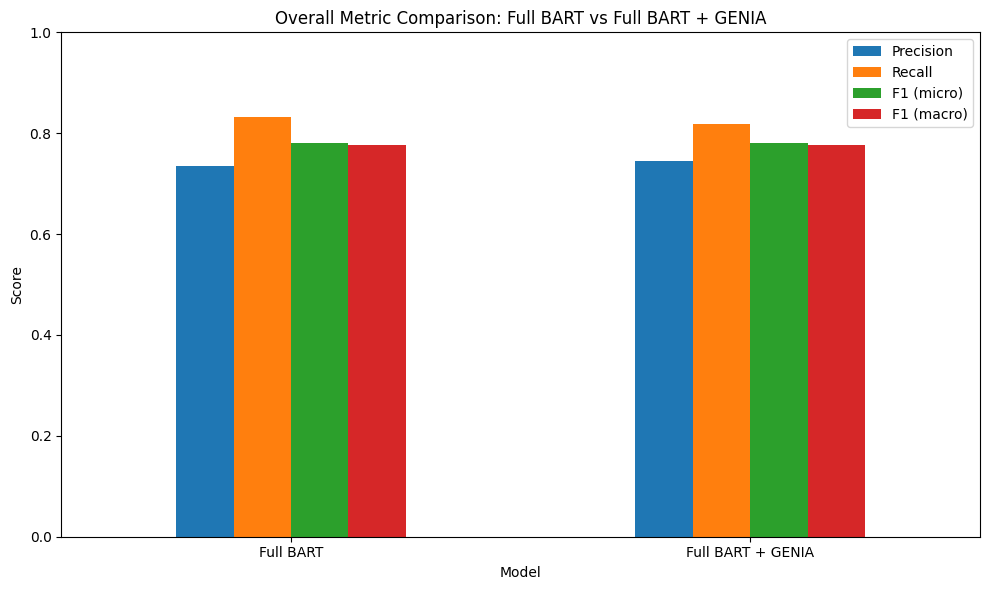

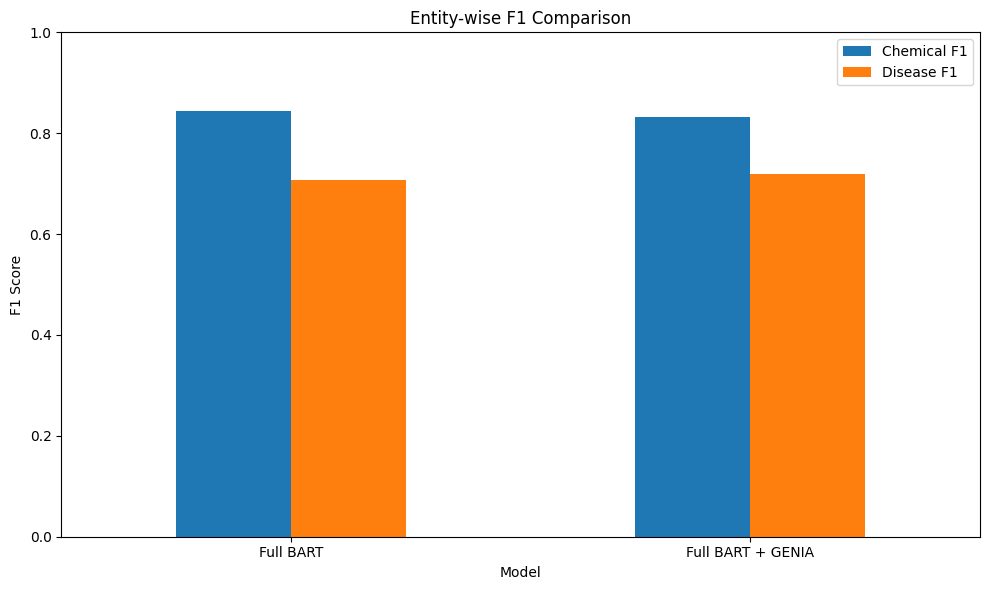

,Base Model,Micro F1 Gain,Macro F1 Gain,Chemical F1 Gain,Disease F1 Gain
0,Full BART,-0.0011,-0.0002,-0.011,0.0105


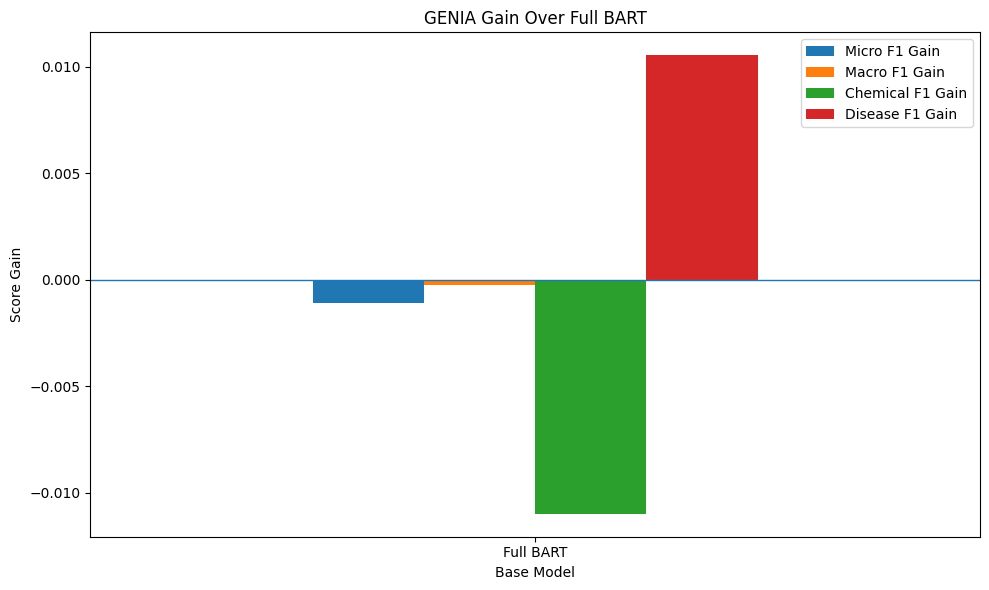

In [ ]:
plot_df = results_df.set_index("Model")[["Precision", "Recall", "F1 (micro)", "F1 (macro)"]]
ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Overall Metric Comparison: Full BART vs Full BART + GENIA")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

entity_df = results_df.set_index("Model")[["Chemical F1", "Disease F1"]]
ax = entity_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Entity-wise F1 Comparison")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

improvement_df = pd.DataFrame({
    "Base Model": ["Full BART"],
    "Micro F1 Gain": [
        bart_genia_test_results["eval_f1_micro"] - bart_test_results["eval_f1_micro"]
    ],
    "Macro F1 Gain": [
        bart_genia_test_results["eval_f1_macro"] - bart_test_results["eval_f1_macro"]
    ],
    "Chemical F1 Gain": [
        bart_genia_test_results["eval_Chemical_f1"] - bart_test_results["eval_Chemical_f1"]
    ],
    "Disease F1 Gain": [
        bart_genia_test_results["eval_Disease_f1"] - bart_test_results["eval_Disease_f1"]
    ]
})

display(improvement_df.round(4))

ax = improvement_df.set_index("Base Model").plot(kind="bar", figsize=(10, 6))
ax.set_title("GENIA Gain Over Full BART")
ax.set_ylabel("Score Gain")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
